# MNIST handwritten digits classification with MLPs

In this notebook, we'll train a multi-layer perceptron model to classify MNIST digits using **PyTorch**. 

First, the needed imports. 

In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    
print('Using PyTorch version:', torch.__version__, ' Device:', device)

Using PyTorch version: 2.7.0+cu126  Device: cuda


## Data

Next we'll load the MNIST data.  First time we may have to download the data, which can take a while.

Note that we are here using the MNIST test data for *validation*, instead of for testing the final model.

In [2]:
batch_size = 32

train_dataset = datasets.MNIST('./data', 
                               train=True, 
                               download=True, 
                               transform=transforms.ToTensor())

validation_dataset = datasets.MNIST('./data', 
                                    train=False, 
                                    transform=transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, 
                                                batch_size=batch_size, 
                                                shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.16MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 375kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.76MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.54MB/s]


The train and test data are provided via data loaders that provide iterators over the datasets. The first element of training data (`X_train`) is a 4th-order tensor of size (`batch_size`, 1, 28, 28), i.e. it consists of a batch of images of size 1x28x28 pixels. `y_train` is a vector containing the correct classes ("0", "1", ..., "9") for each training digit.

In [3]:
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

X_train: torch.Size([32, 1, 28, 28]) type: torch.FloatTensor
y_train: torch.Size([32]) type: torch.LongTensor


Here are the first 10 training digits:

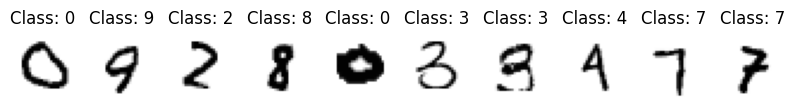

In [4]:
pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.axis('off')
    plt.imshow(X_train[i,:,:,:].numpy().reshape(28,28), cmap="gray_r")
    plt.title('Class: '+str(y_train[i].item()))

## MLP network definition

Let's define the network as a Python class.  We have to write the `__init__()` and `forward()` methods, and PyTorch will automatically generate a `backward()` method for computing the gradients for the backward pass.

Finally, we define an optimizer to update the model parameters based on the computed gradients.  We select *stochastic gradient descent (with momentum)* as the optimization algorithm, and set *learning rate* to 0.01.  Note that there are [several different options](http://pytorch.org/docs/optim.html#algorithms) for the optimizer in PyTorch that we could use instead of *SGD*.

In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 100)  # weight: [28*28, 50]   bias: [50, ]
        self.fc1_drop = nn.Dropout(0.2)
        self.fc2 = nn.Linear(100, 80)
        self.fc2_drop = nn.Dropout(0.2)
        self.fc3 = nn.Linear(80, 10)
        
#         self.relu1 = nn.ReLU() 

    def forward(self, x):
        x = x.view(-1, 28*28)   # [32, 28*28]
        x = F.relu(self.fc1(x))
        x = self.fc1_drop(x)
        x = F.relu(self.fc2(x))
        x = self.fc2_drop(x)   # [32, 10]
        return F.log_softmax(self.fc3(x), dim=1)

model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
criterion = nn.CrossEntropyLoss()

print(model)

Net(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (fc1_drop): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=100, out_features=80, bias=True)
  (fc2_drop): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=80, out_features=10, bias=True)
)


## Learning

Let's now define functions to `train()` and `validate()` the model. 

In [6]:
def train(epoch, log_interval=200):
    # Set model to training mode
    model.train()
    
    # Loop over each batch from the training set
    for batch_idx, (data, target) in enumerate(train_loader):
        # Copy data to GPU if needed
        data = data.to(device)
        target = target.to(device)

        # Zero gradient buffers
        optimizer.zero_grad() 
        
        # Pass data through the network
        output = model(data)

        # Calculate loss
        loss = criterion(output, target)

        # Backpropagate
        loss.backward()  
        
        # Update weights
        optimizer.step()    #  w - alpha * dL / dw
        
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.data.item()))

In [7]:
def validate(loss_vector, accuracy_vector):
    model.eval()
    val_loss, correct = 0, 0
    for data, target in validation_loader:
        data = data.to(device)
        target = target.to(device)
        output = model(data)
        val_loss += criterion(output, target).data.item()
        pred = output.data.max(1)[1] # get the index of the max log-probability
        correct += pred.eq(target.data).cpu().sum()

    val_loss /= len(validation_loader)
    loss_vector.append(val_loss)

    accuracy = 100. * correct.to(torch.float32) / len(validation_loader.dataset)
    accuracy_vector.append(accuracy)
    
    print('\nValidation set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        val_loss, correct, len(validation_loader.dataset), accuracy))


Now we are ready to train our model using the `train()` function.  An *epoch* means one pass through the whole training data. After each epoch, we evaluate the model using `validate()`. 

In [8]:
%%time
epochs = 10

lossv, accv = [], []
for epoch in range(1, epochs + 1):
    train(epoch)
    validate(lossv, accv)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.291130
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.960341
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.431040
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.717531
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.700033
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.751410
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.462042
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.568768
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.426769
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.506190

Validation set: Average loss: 0.3406, Accuracy: 9047/10000 (90%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.451857
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.524704
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.414313
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.285367
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.321223
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.686829
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.355695
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.516982
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.46

Let's now visualize how the training progressed. 

* *Loss* is a function of the difference of the network output and the target values.  We are minimizing the loss function during training so it should decrease over time.
* *Accuracy* is the classification accuracy for the test data.

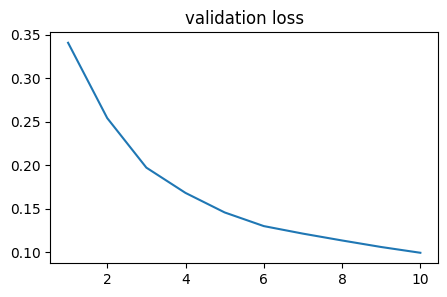

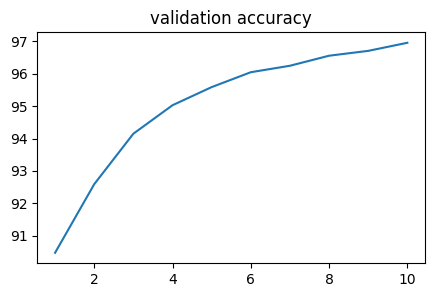

In [9]:
plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epochs+1), lossv)
plt.title('validation loss')

plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epochs+1), accv)
plt.title('validation accuracy');

## Model tuning

Modify the MLP model.  Try to improve the classification accuracy, or experiment with the effects of different parameters.  If you are interested in the state-of-the-art performance on permutation invariant MNIST, see e.g. this [recent paper](https://arxiv.org/abs/1507.02672) by Aalto University / The Curious AI Company researchers.

You can also consult the PyTorch documentation at http://pytorch.org/.


开始实验: 宽层MLP + SGD(momentum)
TunedMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch 01/10 | train loss: 0.2836 | val loss: 0.1371 | val acc: 95.73% | lr: 0.030000
Epoch 02/10 | train loss: 0.1467 | val loss: 0.1120 | val acc: 96.53% | lr: 0.030000
Epoch 03/10 | train loss: 0.1170 | val loss: 0.0990 | val acc: 96.83% | lr: 0.030000
Epoch 04/10 | train loss: 0.1019 | val loss: 0.0841 | val acc: 97.32% | lr: 0.015000
Epoch 05/10 | train loss: 0.0637 | val loss: 0.0649 | val acc: 97.96% | lr: 0.015000
Epoch 06/10 | train loss: 0.0538 | val loss: 0.0644 | val acc: 98.04% | lr: 0.015000
Epoch 07/10 | train loss: 0.0492 | val loss: 0.0639 | val acc: 98.16% | lr: 0.015000
Epoch 08/10 | train loss: 0.0443 | val loss:

d:\anaconda3\envs\dl-hw1\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\anaconda3\envs\dl-hw1\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\anaconda3\envs\dl-hw1\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\dl-hw1\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


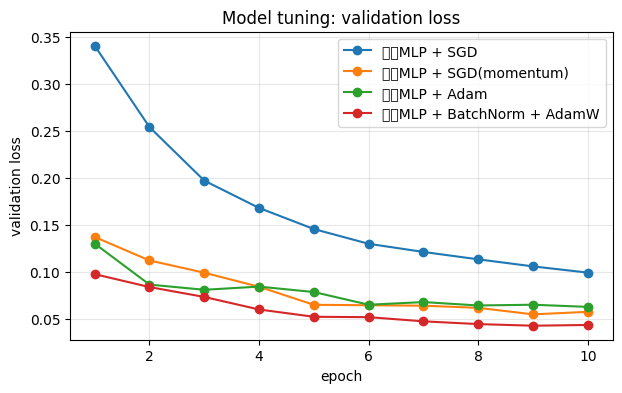

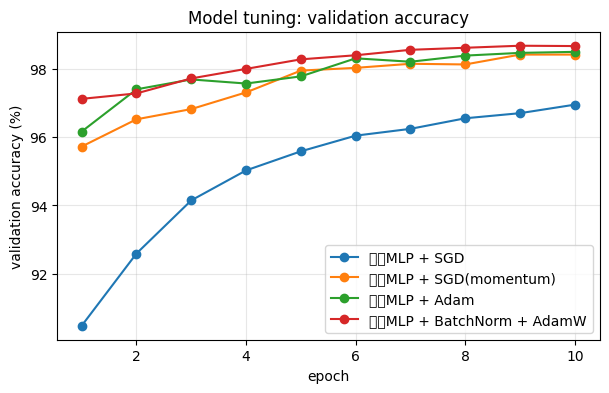

In [11]:
# 为了让多次调参结果尽量可复现，固定随机种子
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


class TunedMLP(nn.Module):
    """可调节深度、宽度、Dropout 和 BatchNorm 的全连接 MLP。"""
    def __init__(self, hidden_dims=(512, 256, 128), dropout=0.25, use_batch_norm=True):
        super(TunedMLP, self).__init__()
        layers = []
        in_features = 28 * 28

        # 逐层构建全连接隐藏层
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_features, hidden_dim))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_dim

        # 输出层直接输出 10 类 logits
        layers.append(nn.Linear(in_features, 10))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


def build_optimizer(model, config):
    """根据配置创建优化器，便于比较 SGD、Adam、AdamW 的效果。"""
    optimizer_name = config['optimizer'].lower()
    lr = config['lr']
    weight_decay = config.get('weight_decay', 0.0)

    if optimizer_name == 'sgd':
        return torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=config.get('momentum', 0.9),
            weight_decay=weight_decay
        )
    if optimizer_name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    raise ValueError(f"不支持的优化器: {config['optimizer']}")


def build_scheduler(optimizer, config, epochs):
    """创建学习率衰减策略；没有指定时返回 None。"""
    scheduler_name = config.get('scheduler')
    if scheduler_name == 'step':
        return torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=config.get('step_size', 4),
            gamma=config.get('gamma', 0.5)
        )
    if scheduler_name == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    return None


def train_one_epoch_tuned(model, optimizer, criterion):
    """训练一个 epoch，并返回训练集平均 loss。"""
    model.train()
    running_loss = 0.0
    total = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        batch_size = data.size(0)
        running_loss += loss.item() * batch_size
        total += batch_size

    return running_loss / total


def evaluate_tuned(model, criterion):
    """在验证集上计算平均 loss 和准确率。"""
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in validation_loader:
            data = data.to(device)
            target = target.to(device)
            output = model(data)
            loss = criterion(output, target)

            batch_size = data.size(0)
            val_loss += loss.item() * batch_size
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += batch_size

    return val_loss / total, 100.0 * correct / total


def run_tuning_experiment(config, epochs=8):
    """运行一次调参实验，并记录每轮训练/验证指标。"""
    print(f"\n开始实验: {config['name']}")
    model = TunedMLP(
        hidden_dims=config['hidden_dims'],
        dropout=config.get('dropout', 0.0),
        use_batch_norm=config.get('use_batch_norm', False)
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config, epochs)

    history = {
        'name': config['name'],
        'model': model,
        'train_losses': [],
        'val_losses': [],
        'val_accs': []
    }

    print(model)
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch_tuned(model, optimizer, criterion)
        val_loss, val_acc = evaluate_tuned(model, criterion)
        history['train_losses'].append(train_loss)
        history['val_losses'].append(val_loss)
        history['val_accs'].append(val_acc)

        if scheduler is not None:
            scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"val acc: {val_acc:.2f}% | "
            f"lr: {current_lr:.6f}"
        )

    history['best_acc'] = max(history['val_accs'])
    history['best_epoch'] = int(np.argmax(history['val_accs']) + 1)
    return history


# 调参方案说明：
# 1. 宽层 + SGD：主要测试隐藏层宽度和更大 momentum 对准确率的影响。
# 2. 深层 + Adam：增加网络深度，并换成自适应学习率优化器。
# 3. 深层 + AdamW + BN：加入 BatchNorm、Dropout 和权重衰减，通常泛化效果更好。
tuning_configs = [
    {
        'name': '宽层MLP + SGD(momentum)',
        'hidden_dims': (256, 128),
        'dropout': 0.20,
        'use_batch_norm': False,
        'optimizer': 'sgd',
        'lr': 0.03,
        'momentum': 0.9,
        'weight_decay': 1e-4,
        'scheduler': 'step',
        'step_size': 4,
        'gamma': 0.5
    },
    {
        'name': '深层MLP + Adam',
        'hidden_dims': (512, 256, 128),
        'dropout': 0.20,
        'use_batch_norm': False,
        'optimizer': 'adam',
        'lr': 1e-3,
        'weight_decay': 1e-5,
        'scheduler': 'cosine'
    },
    {
        'name': '深层MLP + BatchNorm + AdamW',
        'hidden_dims': (512, 256, 128),
        'dropout': 0.25,
        'use_batch_norm': True,
        'optimizer': 'adamw',
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'scheduler': 'cosine'
    }
]

tuning_epochs = 10
tuning_results = [run_tuning_experiment(config, epochs=tuning_epochs) for config in tuning_configs]

# 将前面已经训练过的原始 MLP 曲线也加入对比。
# 原始 accv 中保存的是 torch.Tensor，这里统一转成普通 float，方便后续汇总和画图。
comparison_results = []
if 'lossv' in globals() and 'accv' in globals() and len(lossv) > 0 and len(accv) > 0:
    baseline_result = {
        'name': '原始MLP + SGD',
        'val_losses': [float(loss) for loss in lossv],
        'val_accs': [float(acc.detach().cpu()) if torch.is_tensor(acc) else float(acc) for acc in accv]
    }
    baseline_result['best_acc'] = max(baseline_result['val_accs'])
    baseline_result['best_epoch'] = int(np.argmax(baseline_result['val_accs']) + 1)
    comparison_results.append(baseline_result)
else:
    print('未检测到原始 MLP 的 lossv/accv，请先运行原始模型训练单元。')

comparison_results.extend(tuning_results)

# 输出原始方案和调参方案的最佳验证准确率。
print('\n模型对比结果汇总：')
for result in comparison_results:
    print(f"{result['name']}: best acc = {result['best_acc']:.2f}% (epoch {result['best_epoch']})")

best_result = max(comparison_results, key=lambda item: item['best_acc'])
print(f"\n最佳方案: {best_result['name']}，最佳验证准确率: {best_result['best_acc']:.2f}%")

# 绘制原始方案和不同调参方案的验证 loss / accuracy 曲线。
plt.figure(figsize=(7, 4))
for result in comparison_results:
    epoch_axis = np.arange(1, len(result['val_losses']) + 1)
    plt.plot(epoch_axis, result['val_losses'], marker='o', label=result['name'])
plt.xlabel('epoch')
plt.ylabel('validation loss')
plt.title('Model tuning: validation loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.figure(figsize=(7, 4))
for result in comparison_results:
    epoch_axis = np.arange(1, len(result['val_accs']) + 1)
    plt.plot(epoch_axis, result['val_accs'], marker='o', label=result['name'])
plt.xlabel('epoch')
plt.ylabel('validation accuracy (%)')
plt.title('Model tuning: validation accuracy')
plt.legend()
plt.grid(True, alpha=0.3);

## ResMLP 加分项实现

由于 MLP-Mixer 在当前 MNIST 实验中效果不理想，这里改为实现 ResMLP。ResMLP 仍然属于纯 MLP 视觉模型：先把图像切分为 patch token，然后在 token 维度上使用线性层进行空间信息混合，在 channel 维度上使用两层 MLP 提升特征表达能力，并通过残差连接、Affine 变换和 LayerScale 稳定深层网络训练。

ResMLPMNIST(
  (patch_embed): Conv2d(1, 128, kernel_size=(4, 4), stride=(4, 4))
  (blocks): Sequential(
    (0): ResMLPBlock(
      (token_affine): Affine()
      (token_mix): Linear(in_features=49, out_features=49, bias=True)
      (token_drop): Dropout(p=0.1, inplace=False)
      (channel_affine): Affine()
      (channel_mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
      (drop_path): DropPath()
    )
    (1): ResMLPBlock(
      (token_affine): Affine()
      (token_mix): Linear(in_features=49, out_features=49, bias=True)
      (token_drop): Dropout(p=0.1, inplace=False)
      (channel_affine): Affine()
      (channel_mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): D

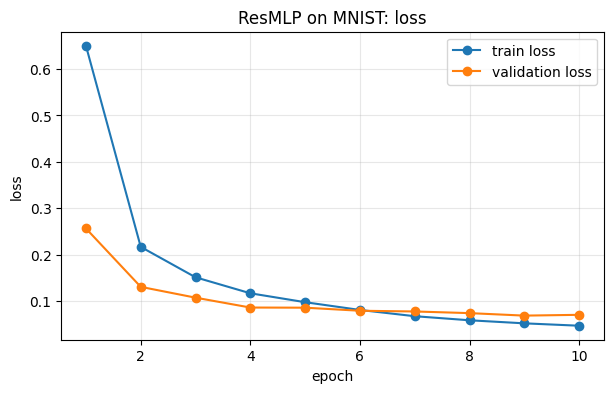

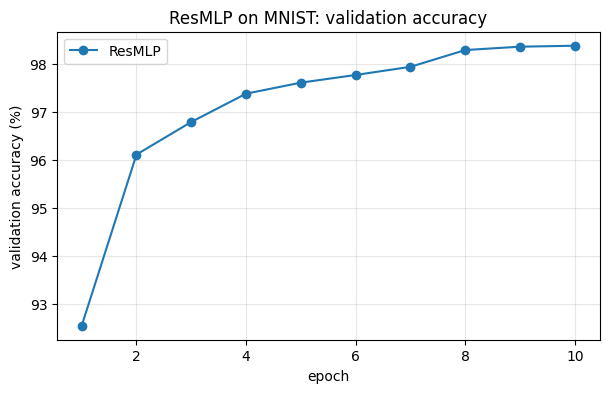

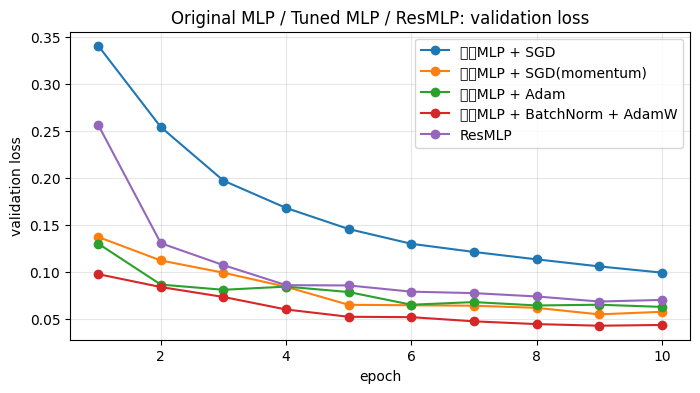

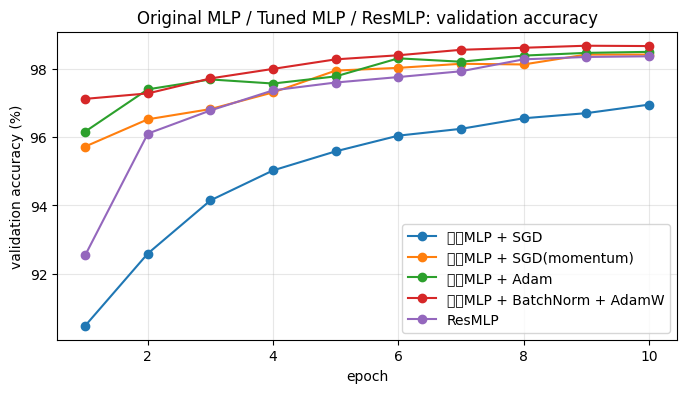

In [15]:
# ResMLP 加分项：在 MNIST 上实现纯 MLP 视觉模型
# ResMLP 的核心结构：PatchEmbedding -> 多个 ResMLPBlock -> Affine -> 全局平均池化 -> 分类头。
# 每个 ResMLPBlock 包含 token mixing 线性层和 channel MLP，两部分都带残差连接。

class Affine(nn.Module):
    """ResMLP 中常用的可学习仿射变换：x * alpha + beta。"""
    def __init__(self, dim):
        super(Affine, self).__init__()
        self.alpha = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        return x * self.alpha + self.beta


class DropPath(nn.Module):
    """随机深度：训练时随机丢弃残差分支，增强泛化；验证时保持恒等映射。"""
    def __init__(self, drop_prob=0.0):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        return x.div(keep_prob) * random_tensor


class ResMLPBlock(nn.Module):
    """ResMLP 基本块：token mixing + channel mixing。"""
    def __init__(self, num_patches, embed_dim, mlp_ratio=4.0, drop=0.1, drop_path=0.0, init_scale=1e-4):
        super(ResMLPBlock, self).__init__()
        hidden_dim = int(embed_dim * mlp_ratio)

        # token mixing：对每个特征通道，在所有 patch token 之间做线性变换。
        self.token_affine = Affine(embed_dim)
        self.token_mix = nn.Linear(num_patches, num_patches)
        self.token_drop = nn.Dropout(drop)
        self.token_layerscale = nn.Parameter(init_scale * torch.ones(embed_dim))

        # channel mixing：对每个 patch 的特征向量做两层 MLP。
        self.channel_affine = Affine(embed_dim)
        self.channel_mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(drop)
        )
        self.channel_layerscale = nn.Parameter(init_scale * torch.ones(embed_dim))
        self.drop_path = DropPath(drop_path)

    def forward(self, x):
        # x: [batch_size, num_patches, embed_dim]
        # 1. token mixing 分支：转置后让 Linear 作用在 num_patches 维度上。
        y = self.token_affine(x)
        y = y.transpose(1, 2)                 # [batch_size, embed_dim, num_patches]
        y = self.token_mix(y)
        y = y.transpose(1, 2)                 # [batch_size, num_patches, embed_dim]
        y = self.token_drop(y)
        x = x + self.drop_path(y * self.token_layerscale)

        # 2. channel mixing 分支：对每个 patch 的 embedding 做 MLP。
        y = self.channel_affine(x)
        y = self.channel_mlp(y)
        x = x + self.drop_path(y * self.channel_layerscale)
        return x


class ResMLPMNIST(nn.Module):
    """适用于 MNIST 的 ResMLP。"""
    def __init__(
        self,
        image_size=28,
        patch_size=4,
        in_channels=1,
        num_classes=10,
        embed_dim=128,
        depth=8,
        mlp_ratio=4.0,
        drop=0.1,
        drop_path_rate=0.1,
        init_scale=1e-4
    ):
        super(ResMLPMNIST, self).__init__()
        assert image_size % patch_size == 0, 'image_size 必须能被 patch_size 整除'
        self.num_patches = (image_size // patch_size) ** 2

        # patch embedding：把 28x28 图像切成 7x7=49 个 patch，并映射到 embed_dim 维。
        self.patch_embed = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        # drop path 随深度线性增加，越靠后的层正则越强。
        drop_path_rates = torch.linspace(0, drop_path_rate, depth).tolist()
        self.blocks = nn.Sequential(*[
            ResMLPBlock(
                num_patches=self.num_patches,
                embed_dim=embed_dim,
                mlp_ratio=mlp_ratio,
                drop=drop,
                drop_path=drop_path_rates[i],
                init_scale=init_scale
            )
            for i in range(depth)
        ])
        self.final_affine = Affine(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self._init_weights()

    def _init_weights(self):
        # 截断正态初始化常用于 ViT/MLP-like 视觉模型。
        for module in self.modules():
            if isinstance(module, (nn.Linear, nn.Conv2d)):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        x = self.patch_embed(x)              # [batch_size, embed_dim, 7, 7]
        x = x.flatten(2).transpose(1, 2)     # [batch_size, 49, embed_dim]
        x = self.blocks(x)
        x = self.final_affine(x)
        x = x.mean(dim=1)                    # 汇总所有 patch token
        return self.head(x)


def count_parameters(model):
    """统计模型可训练参数量。"""
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def train_one_epoch_resmlp(model, optimizer, criterion, max_grad_norm=1.0):
    """训练 ResMLP 一个 epoch，返回训练集平均 loss。"""
    model.train()
    running_loss = 0.0
    total = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        batch_size = data.size(0)
        running_loss += loss.item() * batch_size
        total += batch_size

    return running_loss / total


def evaluate_resmlp(model, criterion):
    """在验证集上评估 ResMLP，返回验证 loss 和准确率。"""
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in validation_loader:
            data = data.to(device)
            target = target.to(device)
            output = model(data)
            loss = criterion(output, target)

            batch_size = data.size(0)
            val_loss += loss.item() * batch_size
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += batch_size

    return val_loss / total, 100.0 * correct / total


# 训练配置：保持 10 轮，便于和原始 MLP、调参 MLP 横向比较。
resmlp_epochs = 10
resmlp_model = ResMLPMNIST(
    image_size=28,
    patch_size=4,
    in_channels=1,
    num_classes=10,
    embed_dim=128,
    depth=8,
    mlp_ratio=4.0,
    drop=0.1,
    drop_path_rate=0.1,
    init_scale=1e-4
).to(device)

resmlp_criterion = nn.CrossEntropyLoss()
resmlp_optimizer = torch.optim.AdamW(resmlp_model.parameters(), lr=1e-3, weight_decay=5e-4)
resmlp_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(resmlp_optimizer, T_max=resmlp_epochs, eta_min=1e-5)

resmlp_train_losses = []
resmlp_val_losses = []
resmlp_val_accs = []

print(resmlp_model)
print(f"ResMLP 可训练参数量: {count_parameters(resmlp_model):,}")
for epoch in range(1, resmlp_epochs + 1):
    train_loss = train_one_epoch_resmlp(resmlp_model, resmlp_optimizer, resmlp_criterion)
    val_loss, val_acc = evaluate_resmlp(resmlp_model, resmlp_criterion)
    resmlp_train_losses.append(train_loss)
    resmlp_val_losses.append(val_loss)
    resmlp_val_accs.append(val_acc)
    resmlp_scheduler.step()

    print(
        f"Epoch {epoch:02d}/{resmlp_epochs} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val acc: {val_acc:.2f}% | "
        f"lr: {resmlp_optimizer.param_groups[0]['lr']:.6f}"
    )

best_resmlp_acc = max(resmlp_val_accs)
best_resmlp_epoch = int(np.argmax(resmlp_val_accs) + 1)
print(f"\nResMLP 最佳验证准确率: {best_resmlp_acc:.2f}% (epoch {best_resmlp_epoch})")

# 绘制 ResMLP 的训练过程曲线。
resmlp_epoch_axis = np.arange(1, resmlp_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(resmlp_epoch_axis, resmlp_train_losses, marker='o', label='train loss')
plt.plot(resmlp_epoch_axis, resmlp_val_losses, marker='o', label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('ResMLP on MNIST: loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.figure(figsize=(7, 4))
plt.plot(resmlp_epoch_axis, resmlp_val_accs, marker='o', label='ResMLP')
plt.xlabel('epoch')
plt.ylabel('validation accuracy (%)')
plt.title('ResMLP on MNIST: validation accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# 如果前面的 Model tuning 单元已经生成 comparison_results，则把 ResMLP 也加入完整对比。
if 'comparison_results' in globals() and len(comparison_results) > 0:
    resmlp_result = {
        'name': 'ResMLP',
        'val_losses': resmlp_val_losses,
        'val_accs': resmlp_val_accs,
        'best_acc': best_resmlp_acc,
        'best_epoch': best_resmlp_epoch
    }
    full_comparison_results = comparison_results + [resmlp_result]

    print('\n加入 ResMLP 后的完整对比结果：')
    for result in full_comparison_results:
        print(f"{result['name']}: best acc = {result['best_acc']:.2f}% (epoch {result['best_epoch']})")

    full_best_result = max(full_comparison_results, key=lambda item: item['best_acc'])
    print(f"\n完整对比最佳方案: {full_best_result['name']}，最佳验证准确率: {full_best_result['best_acc']:.2f}%")

    plt.figure(figsize=(8, 4))
    for result in full_comparison_results:
        epoch_axis = np.arange(1, len(result['val_losses']) + 1)
        plt.plot(epoch_axis, result['val_losses'], marker='o', label=result['name'])
    plt.xlabel('epoch')
    plt.ylabel('validation loss')
    plt.title('Original MLP / Tuned MLP / ResMLP: validation loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.figure(figsize=(8, 4))
    for result in full_comparison_results:
        epoch_axis = np.arange(1, len(result['val_accs']) + 1)
        plt.plot(epoch_axis, result['val_accs'], marker='o', label=result['name'])
    plt.xlabel('epoch')
    plt.ylabel('validation accuracy (%)')
    plt.title('Original MLP / Tuned MLP / ResMLP: validation accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3);
else:
    print('\n提示：如需把 ResMLP 和原始/调参 MLP 放在同一张图中，请先运行 Model tuning 单元。')
